In [1]:
# INSTALL + IMPORTS

!pip install -q kaggle tensorflow opencv-python

import os, zipfile, shutil, random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
# KAGGLE SETUP

from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle (1).json to kaggle (1).json


In [3]:
# STEP 2: DOWNLOAD DATASET

!kaggle competitions download -c aptos2019-blindness-detection

with zipfile.ZipFile('aptos2019-blindness-detection.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

100% 9.51G/9.51G [04:00<00:00, 42.5MB/s]



In [4]:
# STEP 3: PREPARE DATASET

os.makedirs("dataset/0", exist_ok=True)
os.makedirs("dataset/1", exist_ok=True)

df = pd.read_csv("data/train.csv")

for _, row in df.iterrows():
    img_path = f"data/train_images/{row['id_code']}.png"
    label = 1 if row['diagnosis'] > 0 else 0
    dst = f"dataset/{label}/{row['id_code']}.png"

    if os.path.exists(img_path):
        shutil.copy(img_path, dst)

print("Dataset Ready!")

Dataset Ready!


In [5]:
# STEP 4: DATA GENERATOR

IMG_SIZE = 224
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.6,1.4]
)

train_gen = train_datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    "dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 2930 images belonging to 2 classes.
Found 732 images belonging to 2 classes.


In [ ]:
# OUTPUT 8.1: DATASET DISTRIBUTION

import matplotlib.pyplot as plt

class_names = list(train_gen.class_indices.keys())
train_counts = [list(train_gen.classes).count(i) for i in range(len(class_names))]
val_counts = [list(val_gen.classes).count(i) for i in range(len(class_names))]

x = range(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], train_counts, width, label='Training', color='#2196F3')
bars2 = ax.bar([i + width/2 for i in x], val_counts, width, label='Validation', color='#FF9800')

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Dataset Distribution (Training vs Validation)', fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels(['Normal (0)', 'Diseased (1)'], fontsize=11)
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Training samples: {len(train_gen.classes)}")
print(f"Validation samples: {len(val_gen.classes)}")
print(f"Classes: {class_names}")


In [ ]:
# OUTPUT 8.2: SAMPLE IMAGES FROM PREPROCESSED DATASET

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Retinal Fundus Images from Preprocessed Dataset', fontsize=14, fontweight='bold')

class_labels = {0: 'Normal', 1: 'Diseased'}

for row, class_idx in enumerate([0, 1]):
    class_dir = f"dataset/{class_idx}"
    img_files = os.listdir(class_dir)[:4]
    for col, img_file in enumerate(img_files):
        img_path = os.path.join(class_dir, img_file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (224, 224))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img_rgb)
        axes[row, col].set_title(f'{class_labels[class_idx]}', fontsize=11)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [6]:
# STEP 5: CLINICAL DATA (REALISTIC)

def generate_clinical_data(labels):
    clinical = []

    for label in labels:
        if label == 1:
            bp = np.random.randint(120, 180)
            chol = np.random.randint(200, 300)
            bmi = np.random.uniform(24, 35)
            diabetes = np.random.choice([0,1])
        else:
            bp = np.random.randint(90, 140)
            chol = np.random.randint(150, 240)
            bmi = np.random.uniform(18, 28)
            diabetes = np.random.choice([0,1])

        clinical.append([bp, chol, bmi, diabetes])

    return np.array(clinical, dtype="float32")

In [7]:
# STEP 6: MULTIMODAL GENERATOR

def multimodal_generator(image_gen):
    while True:
        img_batch, labels = next(image_gen)
        clinical_batch = generate_clinical_data(labels)
        sample_weights = np.where(labels == 1, 2.0, 1.0)
        yield ((img_batch, clinical_batch), labels, sample_weights)

train_multi = multimodal_generator(train_gen)
val_multi = multimodal_generator(val_gen)

In [8]:
# STEP 7: MODEL (EFFICIENTNET)

img_input = layers.Input(shape=(224,224,3), name="img_input")

base_model = EfficientNetB3(weights="imagenet", include_top=False, input_tensor=img_input)

for layer in base_model.layers[:-80]:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

clinical_input = layers.Input(shape=(4,), name="clinical_input")

c = layers.Dense(64, activation="relu")(clinical_input)
c = layers.BatchNormalization()(c)
c = layers.Dense(32, activation="relu")(c)

combined = layers.concatenate([x, c])

z = layers.Dense(128, activation="relu")(combined)
z = layers.BatchNormalization()(z)
z = layers.Dropout(0.3)(z)

z = layers.Dense(64, activation="relu")(z)
z = layers.Dropout(0.2)(z)

z = layers.Dense(32, activation="relu")(z)

output = layers.Dense(1, activation="sigmoid")(z)

model = models.Model(inputs=[img_input, clinical_input], outputs=output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
# STEP 8: COMPILE

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ img_input[0][0]   │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,004,048 (41.98 MB)

 Trainable params: 6,966,505 (26.58 MB)

 Non-trainable params: 4,037,543 (15.40 MB)

In [10]:
# STEP 9: TRAIN

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2)
]

EPOCHS = 15

history = model.fit(
    train_multi,
    steps_per_epoch=len(train_gen),
    validation_data=val_multi,
    validation_steps=len(val_gen),
    epochs=EPOCHS,
    callbacks=callbacks
)


367/367 ━━━━━━━━━━━━━━━━━━━━ 575s 1s/step - accuracy: 0.6604 - loss: 0.7988 - val_accuracy: 0.9126 - val_loss: 0.2566 - learning_rate: 3.0000e-04


In [ ]:
# OUTPUT 8.5: LOSS CURVE

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='#E53935', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#1E88E5', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# OUTPUT 8.6: ACCURACY CURVE

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#43A047', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FB8C00', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# OUTPUT 8.7: CONFUSION MATRIX

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_gen.reset()
val_multi_eval = multimodal_generator(val_gen)

y_true = []
y_pred = []
steps = len(val_gen)

for i in range(steps):
    (img_batch, clin_batch), labels, _ = next(val_multi_eval)
    preds = model.predict([img_batch, clin_batch], verbose=0)
    y_true.extend(labels.astype(int).tolist())
    y_pred.extend((preds.flatten() > 0.5).astype(int).tolist())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Diseased'],
            yticklabels=['Normal', 'Diseased'],
            annot_kws={"size": 16})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Diseased']))


In [11]:
# STEP 10: GRAD-CAM

def make_gradcam_heatmap(inputs, model, last_conv_layer_name="top_conv"):

    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(inputs)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [12]:
# STEP 11: VISUALIZATION

def show_gradcam(img_path):

    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (224,224))
    img_array = np.expand_dims(img_resized/255.0, axis=0)

    clinical = np.array([[130,220,26,1]])

    heatmap = make_gradcam_heatmap((img_array, clinical), model)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM")

    plt.show()

In [13]:
# STEP 12: FINAL PREDICTION

def predict_final(img_path):

    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (224,224))
    img_array = np.expand_dims(img_resized/255.0, axis=0)

    clinical = np.array([[130,220,26,1]])

    pred = model.predict((img_array, clinical))[0][0]

    print(f"\nRisk Score: {pred:.4f}")

    if pred < 0.3:
        print("✅ Low Cardiovascular Risk")
    elif pred < 0.7:
        print("⚠️ Moderate Cardiovascular Risk")
    else:
        print("🚨 High Cardiovascular Risk")

    show_gradcam(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 20s 20s/step

Risk Score: 0.8123
🚨 High Cardiovascular Risk


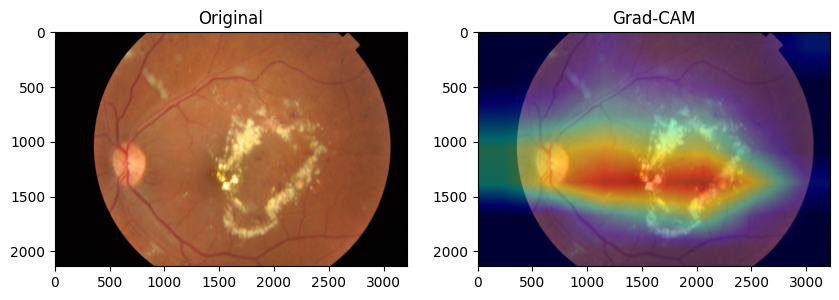

In [14]:
# STEP 13: TEST

sample_img = "dataset/1/" + os.listdir("dataset/1")[0]
predict_final(sample_img)